# EtA, H$_2$O & MeOH: N(t) Simulation + Spectra from Excel

This notebook performs:

- Fits of the N(t) data (EtA, H$_2$O, MeOH)
- ODE simulations for EtA and MeOH (H$_2$O from an exponential fit)
- A stacked plot with 3 rows and 2 columns:
    - left: N(t) (simulation/fit + data), including molecule insets
    - right: IR spectra from All_Spectra_together.xlsx
    - all spectra plotted on top of each other without y-offset
    - color gradient from yellow (1st irradiation) to dark purple (last)
    - wavenumber ranges:
        - EtA: 950–820 cm$^{-1}$, box over 890–860 cm$^{-1}$
        - MeOH: 1070–900 cm$^{-1}$, box over 1070–967 cm$^{-1}$
        - H$_2$O: example range 3800–3000 cm$^{-1}$ (adjustable)
    - y-axis for spectra on the right

The spectra are taken from:
C:\\Users\\taras\\OneDrive\\Dokumente\\MSc\\MA\\2 - Data\\Excel-files\\All_Spectra_together.xlsx


In [1]:
import os
import io
import numpy as np
import matplotlib.pyplot as plt
from numpy.ma.core import size
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.gridspec as gridspec
import pandas as pd
from matplotlib.colors import to_rgb
from typing import Optional, Sequence
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from PIL import Image
import warnings
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import ScalarFormatter

NA = 6.02214076e23  # Avogadro-Zahl (mol^-1)

output_dir = r"/home/tara/PyCharmMiscProject/MA_MPE/output"
os.makedirs(output_dir, exist_ok=True)

stacked_svg = os.path.join(output_dir, "Simulation_1.svg")
stacked_png = os.path.join(output_dir, "Simulation_1.png")
stacked_pdf = os.path.join(output_dir, "Simulation_1.pdf")

molecule_img_dir = output_dir
eta_mol_png  = os.path.join(molecule_img_dir, "EtA.png")
h2o_mol_png  = os.path.join(molecule_img_dir, "water.png")
meoh_mol_png = os.path.join(molecule_img_dir, "MeOH.png")

eta_range_cm1 = (925.0, 820.0)
eta_box_cm1   = (900.0, 855.0)

h2o_range_cm1 = (850.0, 650.0)
h2o_box_cm1   = (800.0, 700.0)

meoh_range_cm1 = (1160.0, 1090.0)
meoh_box_cm1   = (1142.0, 1110.0)

ATOM_COLOR_MAP = {
    "H": "#f5f5f5",
    "C": "#909090",
    "N": "#3050f8",
    "O": "#ff0d0d",
    "S": "#ffd700",
    "P": "#ff8c00",
}
ATOM_RADIUS_MAP = {
    "H": 0.22,
    "C": 0.35,
    "N": 0.33,
    "O": 0.33,
    "S": 0.45,
    "P": 0.4,
}
DEFAULT_ATOM_COLOR = "#b0b0b0"
DEFAULT_ATOM_RADIUS = 0.3
BOND_COLOR = "#4b4b4b"

output_dir, stacked_png, stacked_pdf


('/home/tara/PyCharmMiscProject/MA_MPE/output',
 '/home/tara/PyCharmMiscProject/MA_MPE/output/Simulation_1.png',
 '/home/tara/PyCharmMiscProject/MA_MPE/output/Simulation_1.pdf')

## Molecule-Helper (RDKit, PNG-Insets)


In [2]:
def smiles_to_3d_mol(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Could not parse SMILES: {smiles}")
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, AllChem.ETKDG())
    AllChem.MMFFOptimizeMolecule(mol)
    return mol

def _rotate_coords(coords: np.ndarray, elev_deg: float = 25.0, azim_deg: float = 45.0):
    elev = np.deg2rad(elev_deg)
    azim = np.deg2rad(azim_deg)
    Rz = np.array([
        [np.cos(azim), -np.sin(azim), 0.0],
        [np.sin(azim),  np.cos(azim), 0.0],
        [0.0,           0.0,          1.0],
    ])
    Rx = np.array([
        [1.0, 0.0,           0.0],
        [0.0, np.cos(elev), -np.sin(elev)],
        [0.0, np.sin(elev),  np.cos(elev)],
    ])
    return coords @ (Rz @ Rx).T

def _shade_color(color: str, depth: float, depth_min: float, depth_max: float):
    rgb = np.array(to_rgb(color))
    if depth_max - depth_min < 1e-8:
        return tuple(rgb)
    depth_norm = (depth - depth_min) / (depth_max - depth_min)
    shade = 0.45 + 0.55 * depth_norm
    return tuple(np.clip(rgb * shade, 0.0, 1.0))

def _render_pseudo3d_image(mol, size=(300, 300), elev=25.0, azim=45.0, dpi=200):
    conf = mol.GetConformer()
    coords = np.array(conf.GetPositions(), dtype=float)
    coords -= coords.mean(axis=0)
    span = np.max(np.linalg.norm(coords[:, :2], axis=1))
    if span > 0:
        coords /= span
    coords *= 0.85
    rotated = _rotate_coords(coords, elev_deg=elev, azim_deg=azim)
    xy = rotated[:, :2]
    depth = rotated[:, 2]
    depth_min, depth_max = depth.min(), depth.max()
    fig = Figure(figsize=(size[0] / dpi, size[1] / dpi), dpi=dpi)
    canvas = FigureCanvasAgg(fig)
    ax = fig.add_axes([0.0, 0.0, 1.0, 1.0])
    ax.set_axis_off()
    scale = size[0] / 400.0
    bond_lw = 3.0 * scale
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        depth_avg = 0.5 * (depth[i] + depth[j])
        color = _shade_color(BOND_COLOR, depth_avg, depth_min, depth_max)
        line = Line2D(
            [xy[i, 0], xy[j, 0]],
            [xy[i, 1], xy[j, 1]],
            lw=bond_lw,
            color=color,
            solid_capstyle="round",
        )
        ax.add_line(line)
    order = np.argsort(depth)
    for idx in order:
        atom = mol.GetAtomWithIdx(int(idx))
        symbol = atom.GetSymbol()
        color = ATOM_COLOR_MAP.get(symbol, DEFAULT_ATOM_COLOR)
        radius = ATOM_RADIUS_MAP.get(symbol, DEFAULT_ATOM_RADIUS)
        shaded = _shade_color(color, depth[idx], depth_min, depth_max)
        circle = Circle(
            (xy[idx, 0], xy[idx, 1]),
            radius=radius * scale,
            edgecolor=(0.1, 0.1, 0.1),
            linewidth=0.7 * scale,
            facecolor=shaded,
        )
        ax.add_patch(circle)
    pad = 1.0
    ax.set_xlim(-pad, pad)
    ax.set_ylim(-pad, pad)
    ax.set_aspect("equal")
    canvas.draw()
    buf = np.frombuffer(canvas.tostring_rgb(), dtype=np.uint8)
    image = buf.reshape(canvas.get_width_height()[1], canvas.get_width_height()[0], 3)
    plt.close(fig)
    return image

def mol_image_array(smiles: str, size=(300, 300), elev=25.0, azim=45.0):
    mol = smiles_to_3d_mol(smiles)
    try:
        return _render_pseudo3d_image(mol, size=size, elev=elev, azim=azim)
    except Exception as exc:
        warnings.warn(
            f"Pseudo-3D rendering failed for {smiles}: {exc}. Falling back to 2D drawing.",
            RuntimeWarning,
        )
        AllChem.Compute2DCoords(mol)
        img = Draw.MolToImage(mol, size=size)
        return np.array(img)

def add_molecule_inset_from_png(ax,
                                image_path: str,
                                loc: str = 'upper right',
                                width: str = '25%',
                                height: str = '25%',
                                border: bool = False,
                                axes_box: Optional[Sequence[float]] = None):
    if axes_box is not None:
        inset_ax = ax.inset_axes(axes_box, transform=ax.transAxes)
    else:
        inset_ax = inset_axes(ax, width=width, height=height, loc=loc, borderpad=0.0)
    img = mpimg.imread(image_path)
    inset_ax.imshow(img)
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    if not border:
        for spine in inset_ax.spines.values():
            spine.set_visible(False)
    return inset_ax

def add_molecule_inset_from_smiles(ax,
                                   smiles: str,
                                   loc: str = 'upper right',
                                   width: str = '25%',
                                   height: str = '25%',
                                   border: bool = False,
                                   size_px=(300, 300)):
    inset_ax = inset_axes(ax, width=width, height=height, loc=loc, borderpad=0.0)
    img_arr = mol_image_array(smiles, size=size_px)
    inset_ax.imshow(img_arr)
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    if not border:
        for spine in inset_ax.spines.values():
            spine.set_visible(False)
    return inset_ax

def safe_add_molecule_inset(ax,
                            png_path: str,
                            smiles: str,
                            loc: str = 'upper right',
                            width: str = '25%',
                            height: str = '25%',
                            border: bool = False,
                            size_px=(300, 300),
                            axes_box=None):
    if png_path and os.path.exists(png_path):
        return add_molecule_inset_from_png(ax, png_path, loc=loc,
                                           width=width, height=height,
                                           border=border,
                                           axes_box=axes_box)
    if smiles:
        warnings.warn(f"PNG {png_path} fehlt – rendere Molekül für {smiles} direkt.")
        return add_molecule_inset_from_smiles(ax, smiles, loc=loc,
                                              width=width, height=height,
                                              border=border,
                                              size_px=size_px)
    warnings.warn("Kein PNG-Pfad oder SMILES verfügbar, inset wird übersprungen.")
    return None


## 3D-Molecule-Previews render and save


In [3]:

molecule_specs = [
    {"label": "EtA",   "smiles": "OCCN", "path": eta_mol_png},
    {"label": "H$_2$O", "smiles": "O",    "path": h2o_mol_png},
    {"label": "CH$_3$OH",  "smiles": "CO",   "path": meoh_mol_png},
]

render_errors = []
for spec in molecule_specs:
    # Wenn ein fertiges PNG bereits existiert, einfach verwenden
    if os.path.exists(spec["path"]):
        print(f"Verwende vorhandenes PNG für {spec['label']}: {spec['path']}")
        continue

    # Nur wenn KEIN PNG vorhanden ist, aus SMILES rendern
    try:
        img_array = mol_image_array(spec["smiles"], size=(400, 400))
        Image.fromarray(img_array).save(spec["path"])
        print(f"3D-Bild für {spec['label']} gerendert und gespeichert: {spec['path']}")
    except Exception as exc:
        warnings.warn(f"Rendering für {spec['label']} fehlgeschlagen: {exc}")
        render_errors.append(spec["label"])

if render_errors:
    print("Note: At least one molecule could not be found.")
else:
    print("All molecules were rendered successfully.")


Verwende vorhandenes PNG für EtA: /home/tara/PyCharmMiscProject/MA_MPE/output/EtA.png
Verwende vorhandenes PNG für H$_2$O: /home/tara/PyCharmMiscProject/MA_MPE/output/water.png
Verwende vorhandenes PNG für CH$_3$OH: /home/tara/PyCharmMiscProject/MA_MPE/output/MeOH.png
All molecules were rendered successfully.


## Vorschau der gespeicherten Moleküle


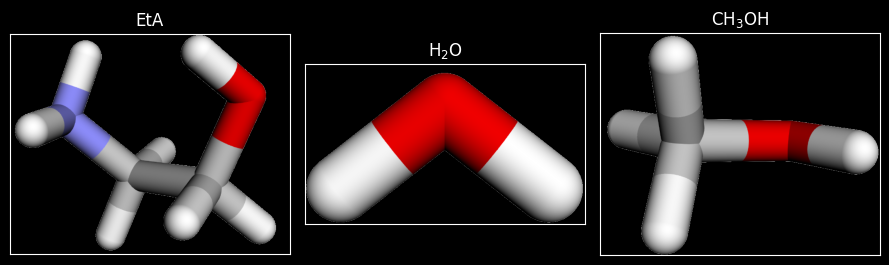

In [4]:
fig, axes = plt.subplots(1, len(molecule_specs), figsize=(3 * len(molecule_specs), 3))
if len(molecule_specs) == 1:
    axes = [axes]

for ax, spec in zip(axes, molecule_specs):
    if not os.path.exists(spec['path']):
        ax.set_title(f"{spec['label']} fehlt")
        ax.axis('off')
        continue
    ax.imshow(mpimg.imread(spec['path']))
    ax.set_title(spec['label'])
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


## Simulations-Helfer: Bandstärken, Fits, ODEs


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

NA = 6.02214076e23  # molecules/mol


def compute_band_strength_A(S, sigma_S,
                            thickness_cm, sigma_thickness_cm,
                            density_g_cm3, sigma_density_g_cm3,
                            molar_mass_g_mol, sigma_molar_mass_g_mol):
    """
    Computes band strength A (cm/molecule) from integrated absorbance area S
    using your convention with ln(10) already baked into the formula here:

        A = ln(10) * M * S / (rho * NA * thickness)

    NOTE: You explicitly use N = S/A (no ln10 there).
    """
    LN10 = 2.3026  # ln(10)

    A = (LN10 * molar_mass_g_mol * S) / (density_g_cm3 * NA * thickness_cm)

    rel_S  = sigma_S / S if S != 0 else 0.0
    rel_M  = sigma_molar_mass_g_mol / molar_mass_g_mol if molar_mass_g_mol != 0 else 0.0
    rel_rho = sigma_density_g_cm3 / density_g_cm3 if density_g_cm3 != 0 else 0.0
    rel_d  = sigma_thickness_cm / thickness_cm if thickness_cm != 0 else 0.0

    rel_A2 = rel_S**2 + rel_M**2 + rel_rho**2 + rel_d**2
    sigma_A = A * np.sqrt(rel_A2)
    return A, sigma_A

def propagate_error_deltaN(S, sigma_S, A, sigma_A):
    deltaN = S / A
    term_S = (sigma_S / A) ** 2
    term_A = (S * sigma_A / A**2) ** 2
    sigma_deltaN = np.sqrt(term_S + term_A)
    return deltaN, sigma_deltaN

def propagate_error_Nphi(N0, sigma_N0, deltaN, sigma_deltaN):
    Nphi = N0 + deltaN
    sigma_Nphi = np.sqrt(sigma_N0**2 + sigma_deltaN**2)
    return Nphi, sigma_Nphi
    print("names:", names)
    print("S0:", S0)
    print("Sirr:", Sirr)
    print("err:", err)

def fit_parent_species(label,
                       thickness_cm, sigma_thickness_cm,
                       density_g_cm3, sigma_density_g_cm3,
                       molar_mass_g_mol, sigma_molar_mass_g_mol,
                       S0, sigma_S0,
                       S_irr, sigma_S_irr,
                       times_min,
                       absolute_S=False,
                       ylim=None,
                       model="exp",
                       show_h2o_k_sweep=True):
    """
    Compute A0 from film properties and reference area S0, convert areas to N(t),
    and fit either:
      - model="exp":        N(t) = N_inf + (N0 - N_inf) * exp(-k t)
      - model="compaction": N(t) = N_inf + (N0 - N_inf) * exp(-k_d t)
                            + B * (1 - exp(-k_c t)) * exp(-k_d t)

    If label == "H2O" and model == "compaction", the plot additionally overlays
    several curves with different (k_d, k_c) to build intuition.
    """
    # 1) Band strength from reference point
    A0, sigma_A0 = compute_band_strength_A(
        S0, sigma_S0,
        thickness_cm, sigma_thickness_cm,
        density_g_cm3, sigma_density_g_cm3,
        molar_mass_g_mol, sigma_molar_mass_g_mol
    )
    print(f"\n=== {label} ===")
    print("Bandstärke A0: {:.3e} ± {:.3e}".format(A0, sigma_A0))

    # 2) Build N(t) points (include t=0)
    N0, sigma_N0 = propagate_error_deltaN(S0, sigma_S0, A0, sigma_A0)
    print("Initial N0: {:.3e} ± {:.3e} molec/cm^2".format(N0, sigma_N0))

    times_s = np.asarray(times_min, dtype=float) * 60.0
    t_list = [0.0]
    N_list = [N0]
    sigma_N_list = [sigma_N0]

    print("\nIrradiation steps:")
    for t_i, S_t, sigma_S_t in zip(times_s, S_irr, sigma_S_irr):
        if absolute_S:
            # S_t is the absolute integrated area at time t
            N_t, sigma_N_t = propagate_error_deltaN(S_t, sigma_S_t, A0, sigma_A0)
        else:
            # backwards compatible: S_t is ΔS and N(t)=N0+ΔN(t)
            deltaN_t, sigma_deltaN_t = propagate_error_deltaN(S_t, sigma_S_t, A0, sigma_A0)
            N_t, sigma_N_t = propagate_error_Nphi(N0, sigma_N0, deltaN_t, sigma_deltaN_t)

        t_list.append(float(t_i))
        N_list.append(float(N_t))
        sigma_N_list.append(float(sigma_N_t))

        print(f"t = {t_i:.1f} s ({t_i/60:.1f} min)")
        if absolute_S:
            print("  S(t)  = {:.3e} ± {:.3e}".format(S_t, sigma_S_t))
        else:
            print("  ΔS(t) = {:.3e} ± {:.3e}".format(S_t, sigma_S_t))
        print("  N(t)  = {:.3e} ± {:.3e} molec/cm^2".format(N_t, sigma_N_t))

    t = np.asarray(t_list, dtype=float)
    N = np.asarray(N_list, dtype=float)
    sigma_N = np.asarray(sigma_N_list, dtype=float)

    # --- 3) Fit
    N0_fit = float(N[0])

    def exp_decay(t_, k_eff, N_inf):
        return N_inf + (N0_fit - N_inf) * np.exp(-k_eff * t_)

    def compaction_decay(t_, k_d, k_c, B, N_inf):
        return (N_inf
                + (N0_fit - N_inf) * np.exp(-k_d * t_)
                + B * (1.0 - np.exp(-k_c * t_)) * np.exp(-k_d * t_))

    # Use uncertainties as weights if available (avoid zeros)
    sigma_fit = np.clip(sigma_N, 1e-30, np.inf)

    if model == "exp":
        p0 = [1e-5, max(float(np.min(N)), 0.0)]
        lb = [0.0, 0.0]
        ub = [1e-2, max(2.0 * float(np.max(N)), 1e-30)]
        popt, pcov = curve_fit(
            exp_decay, t, N, p0=p0, bounds=(lb, ub),
            sigma=sigma_fit, absolute_sigma=True, maxfev=20000
        )
        k_eff_fit, N_inf_fit = popt
        dk_eff, dN_inf = np.sqrt(np.diag(pcov))
        N_fit_fn = lambda tt: exp_decay(tt, *popt)
        print(f"Ninf={N_inf_fit}")

        extra_params = {}

    elif model == "compaction":
        # guesses: k_d slower, k_c faster
        k_d0 = 5e-6
        k_c0 = 1e-4
        B0 = max((float(np.max(N)) - N0_fit), 0.0)
        Ninf0 = max(float(np.min(N)), 0.0)

        p0 = [k_d0, k_c0, B0, Ninf0]
        lb = [0.0, 0.0, 0.0, 0.0]
        ub = [1e-2, 1e-1, max(5.0 * float(np.max(N)), 1e-30), max(2.0 * float(np.max(N)), 1e-30)]

        popt, pcov = curve_fit(
            compaction_decay, t, N, p0=p0, bounds=(lb, ub),
            sigma=sigma_fit, absolute_sigma=True, maxfev=50000
        )
        k_d_fit, k_c_fit, B_fit, N_inf_fit = popt
        perr = np.sqrt(np.diag(pcov))
        dk_d, dk_c, dB, dN_inf = perr

        # keep return signature compatible with earlier notebook:
        # k_eff_fit is reported as k_d for compaction model
        k_eff_fit, dk_eff = k_d_fit, dk_d
        N_fit_fn = lambda tt: compaction_decay(tt, *popt)

        extra_params = {"k_c": (k_c_fit, dk_c), "B": (B_fit, dB)}

        print(f"Compaction fit parameters:")
        print(f"  k_d = {k_d_fit:.3e} ± {dk_d:.3e} 1/s")
        print(f"  k_c = {k_c_fit:.3e} ± {dk_c:.3e} 1/s")
        print(f"  B   = {B_fit:.3e} ± {dB:.3e}")
        print(f"  N∞  = {N_inf_fit:.3e} ± {dN_inf:.3e} molec/cm^2")

    else:
        raise ValueError("model must be 'exp' or 'compaction'")

    # --- 4) Plot
    fig, ax = plt.subplots()
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")

    ax.errorbar(t, N, yerr=sigma_N, fmt='o', capsize=3, label=f'{label} data')

    t_fit = np.linspace(float(t.min()), float(t.max()), 300)
    ax.plot(t_fit, N_fit_fn(t_fit), '-', label=f'{label} fit ({model})')

    # For the first H2O plot: overlay several (k_d, k_c) combinations for intuition
    if label.lower() in ("h2o", "water") and model == "compaction" and show_h2o_k_sweep:
        k_d_fit, k_c_fit, B_fit, _Ninf_fit = popt
        kd_factors = [0.5, 1.0, 2.0]
        kc_factors = [0.2, 1.0, 5.0]

        # keep only a small, readable subset (8 curves max)
        combos = []
        for a in kd_factors:
            for b in kc_factors:
                combos.append((a, b))
        combos = combos[:8]

        for a, b in combos:
            kd = k_d_fit * a
            kc = k_c_fit * b
            ax.plot(
                t_fit,
                compaction_decay(t_fit, kd, kc, B_fit, N_inf_fit),
                '--',
                linewidth=1.2,
                label=f'k_d×{a:g}, k_c×{b:g}'
            )

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_xlabel("t (s)")
    ax.set_ylabel(f"N_{{{label}}} (molecules cm$^{{-2}}$)")
    ax.legend(fontsize=8)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(True)

    fig.tight_layout()
    plt.show()

    return k_eff_fit, dk_eff, N_inf_fit, dN_inf, t, N, sigma_N, N0
def fit_choline_from_areas(label, S_chol, sigma_S_chol, times_min):
    times_s = times_min * 60.0
    S0 = 0.0

    def form_model(t_, k_form, S_inf):
        return S_inf - (S_inf - S0) * np.exp(-k_form * t_)

    k0_guess = 1e-4
    S_inf_guess = S_chol[-1]
    p0 = [k0_guess, S_inf_guess]
    bounds = ([0.0, 0.0], [1e-1, 10.0 * max(S_chol)])

    popt, pcov = curve_fit(
        form_model, times_s, S_chol, p0=p0,
        sigma=sigma_S_chol, absolute_sigma=True,
        bounds=bounds, maxfev=10000,
    )
    k_form, S_inf = popt
    dk_form, dS_inf = np.sqrt(np.diag(pcov))
    print(f"\n=== {label} (Cholin) ===")
    print(f"k_form = {k_form:.3e} ± {dk_form:.3e} 1/s")
    print(f"S_inf  = {S_inf:.3e} ± {dS_inf:.3e} (arb. units)")
    return k_form, dk_form, S_inf, dS_inf


def eta_ode(t, y, k_eta, Ninf_eta, f_rad, f_cholin):
    E, R, C = y
    loss_E = k_eta * (E - Ninf_eta)
    dE_dt = -loss_E
    dR_dt = f_rad    * loss_E
    dC_dt = f_cholin * loss_E
    return [dE_dt, dR_dt, dC_dt]
    print("names:", names)
    print("S0:", S0)
    print("Sirr:", Sirr)
    print("err:", err)


def meoh_ode(t, y, k_meoh, Ninf_meoh, f_dehyd, f_CH3, f_OH):
    M, D, CH3, OH = y
    loss_M = k_meoh * (M - Ninf_meoh)
    dM_dt   = -loss_M
    dD_dt   = f_dehyd * loss_M
    dCH3_dt = f_CH3   * loss_M
    dOH_dt  = f_OH    * loss_M
    return [dM_dt, dD_dt, dCH3_dt, dOH_dt]



## Spektren: Excel-Import, Farbverlauf, Panels


In [6]:
def make_gradient_colors(n, start_color="#ffff00", end_color="#4b0082"):
    if n <= 0:
        return []
    if n == 1:
        return [to_rgb(start_color)]
    sr, sg, sb = to_rgb(start_color)
    er, eg, eb = to_rgb(end_color)
    colors = []
    for i in range(n):
        f = i / (n - 1)
        r = sr + (er - sr) * f
        g = sg + (eg - sg) * f
        b = sb + (eb - sb) * f
        colors.append((r, g, b))
    return colors

import matplotlib.cm as cm
from matplotlib.colors import Normalize

def plot_spectra_panel(ax, wn, Y, xrange, box_range=None):
    """Plot multiple spectra on a panel.

    - Plots all spectra columns in Y against wn within xrange.
    - If box_range is given, fills the area between each spectrum and y=0
      inside the integration window (box_range).
    """
    xmin, xmax = xrange
    x_lo = min(xmin, xmax)
    x_hi = max(xmin, xmax)

    mask = (wn >= x_lo) & (wn <= x_hi)
    x_sel = wn[mask]
    Y_sel = Y[mask, :]
    n_spectra = Y_sel.shape[1]

    cmap = cm.get_cmap("magma")
    vals = np.linspace(0.75, 0.05, n_spectra)

    # plot spectra
    for j in range(n_spectra):
        color = cmap(vals[j])
        ax.plot(x_sel, Y_sel[:, j], lw=1, color=color)

    # fill integration window to y=0 (per spectrum)
    if box_range is not None:
        bmin, bmax = box_range
        b_lo, b_hi = min(bmin, bmax), max(bmin, bmax)
        mbox = (wn >= b_lo) & (wn <= b_hi) & mask
        xb = wn[mbox]
        if xb.size > 1:
            Yb = Y[mbox, :]
            for j in range(n_spectra):
                color = cmap(vals[j])
                ax.fill_between(xb, Yb[:, j], 0.0, color=color, alpha=0.18, linewidth=0)

    # y-axis on the right
    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    ax.set_ylabel("Absorbance (a.u.)")

    # IR-Style: high wavenumber on the left
    ax.set_xlim(xmax, xmin)
    ax.invert_xaxis()

    for spine in ("top", "right"):
        ax.spines[spine].set_visible(True)



### Molekülpositionen im Plot manuell anpassen

In der nächsten Code-Zelle kannst du die Position der Molekül-PNGs über die Variablen

```python
ETA_INSET_BOX, H2O_INSET_BOX, MEOH_INSET_BOX
```

steuern.  
Die Tupel haben die Form `(x0, y0, width, height)` in **Achsenkoordinaten** (0..1).  
Einfach Zahlen ändern und die Zelle neu ausführen, bis die Position passt.


## Simulation, Excel-Spektren laden, gestackten Plot erzeugen



=== EtA ===
Bandstärke A0: 1.061e-17 ± 5.593e-19
Initial N0: 6.652e+17 ± 3.679e+16 molec/cm^2

Irradiation steps:
t = 60.0 s (1.0 min)
  S(t)  = 6.983e+00 ± 1.010e-01
  N(t)  = 6.582e+17 ± 3.598e+16 molec/cm^2
t = 300.0 s (5.0 min)
  S(t)  = 6.798e+00 ± 3.300e-02
  N(t)  = 6.408e+17 ± 3.392e+16 molec/cm^2
t = 900.0 s (15.0 min)
  S(t)  = 6.770e+00 ± 4.900e-02
  N(t)  = 6.381e+17 ± 3.396e+16 molec/cm^2
t = 1800.0 s (30.0 min)
  S(t)  = 6.757e+00 ± 2.800e-02
  N(t)  = 6.369e+17 ± 3.368e+16 molec/cm^2
t = 3600.0 s (60.0 min)
  S(t)  = 6.743e+00 ± 3.300e-02
  N(t)  = 6.356e+17 ± 3.365e+16 molec/cm^2
Ninf=6.366189096936535e+17


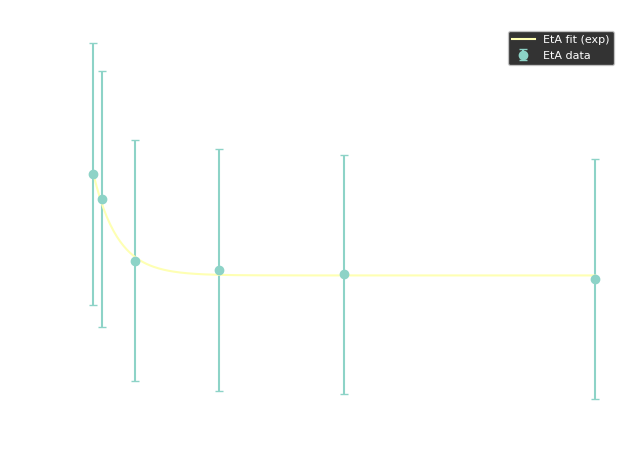


=== H2O ===
Bandstärke A0: 1.278e-17 ± 1.306e-18
Initial N0: 6.324e+16 ± 8.571e+15 molec/cm^2

Irradiation steps:
t = 60.0 s (1.0 min)
  S(t)  = 1.105e+00 ± 9.170e-02
  N(t)  = 8.646e+16 ± 1.138e+16 molec/cm^2
t = 300.0 s (5.0 min)
  S(t)  = 9.685e-01 ± 6.420e-02
  N(t)  = 7.577e+16 ± 9.227e+15 molec/cm^2
t = 900.0 s (15.0 min)
  S(t)  = 8.749e-01 ± 7.210e-02
  N(t)  = 6.845e+16 ± 8.983e+15 molec/cm^2
t = 1800.0 s (30.0 min)
  S(t)  = 9.678e-01 ± 9.050e-02
  N(t)  = 7.571e+16 ± 1.049e+16 molec/cm^2
t = 3600.0 s (60.0 min)
  S(t)  = 7.081e-01 ± 3.800e-03
  N(t)  = 5.540e+16 ± 5.667e+15 molec/cm^2
Compaction fit parameters:
  k_d = 1.025e-04 ± 2.614e-05 1/s
  k_c = 1.000e-01 ± 4.317e+00 1/s
  B   = 1.783e+16 ± 1.590e-15
  N∞  = 1.314e+10 ± 1.104e-17 molec/cm^2


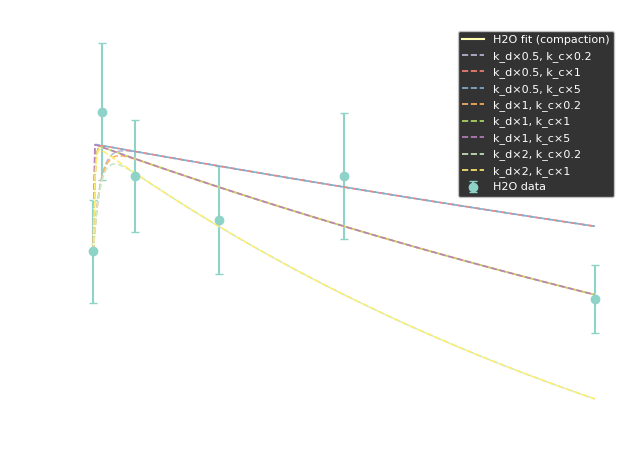


=== MeOH ===
Bandstärke A0: 3.509e-19 ± 1.102e-19
Initial N0: 8.920e+16 ± 3.935e+16 molec/cm^2

Irradiation steps:
t = 60.0 s (1.0 min)
  S(t)  = 8.470e-02 ± 1.000e-03
  N(t)  = 2.414e+17 ± 7.582e+16 molec/cm^2
t = 300.0 s (5.0 min)
  S(t)  = 9.050e-02 ± 3.440e-02
  N(t)  = 2.579e+17 ± 1.271e+17 molec/cm^2
t = 900.0 s (15.0 min)
  S(t)  = 1.013e-01 ± 3.050e-02
  N(t)  = 2.887e+17 ± 1.256e+17 molec/cm^2
t = 1800.0 s (30.0 min)
  S(t)  = 1.061e-01 ± 4.420e-02
  N(t)  = 3.024e+17 ± 1.577e+17 molec/cm^2
t = 3600.0 s (60.0 min)
  S(t)  = 7.310e-02 ± 4.070e-02
  N(t)  = 2.083e+17 ± 1.332e+17 molec/cm^2
Ninf=2.873800534148461e+17


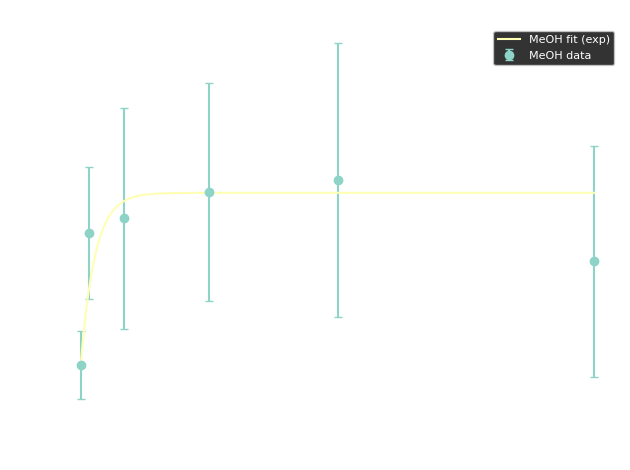


Zusammenfassung der k_eff:
EtA : k_eff = 5.699e-03 ± 1.755e-02 1/s
H2O : k_eff = 1.025e-04 ± 2.614e-05 1/s
MeOH: k_eff = 1.000e-02 ± 1.122e-02 1/s

=== Cholin Peak 1 (Cholin) ===
k_form = 5.704e-02 ± 2.155e-02 1/s
S_inf  = 3.820e+00 ± 5.236e-02 (arb. units)

Cholin-Zusammenfassung:
Peak 1: k_form = 5.704e-02 ± 2.155e-02 1/s
/home/tara/Sync/Methanol ['Subtractionspectra_Methanol1', 'Subtractionspectra_Methanol2', 'Subtractionspectra_Methanol3', 'Subtractionspectra_Methanol4', 'Subtractionspectra_Methanol5', '20240626_Deposition_Methanol_20K_sample1']
/home/tara/Sync/Methanol/Subtractionspectra_Methanol1.CSV
/home/tara/Sync/Methanol/Subtractionspectra_Methanol1.CSV
/home/tara/Sync/Methanol/Subtractionspectra_Methanol1.CSV
/home/tara/Sync/Methanol/Subtractionspectra_Methanol2.CSV
/home/tara/Sync/Methanol/Subtractionspectra_Methanol2.CSV
/home/tara/Sync/Methanol/Subtractionspectra_Methanol2.CSV
/home/tara/Sync/Methanol/Subtractionspectra_Methanol3.CSV
/home/tara/Sync/Methanol/Subtractions

/tmp/ipykernel_80284/3935284289.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("magma")


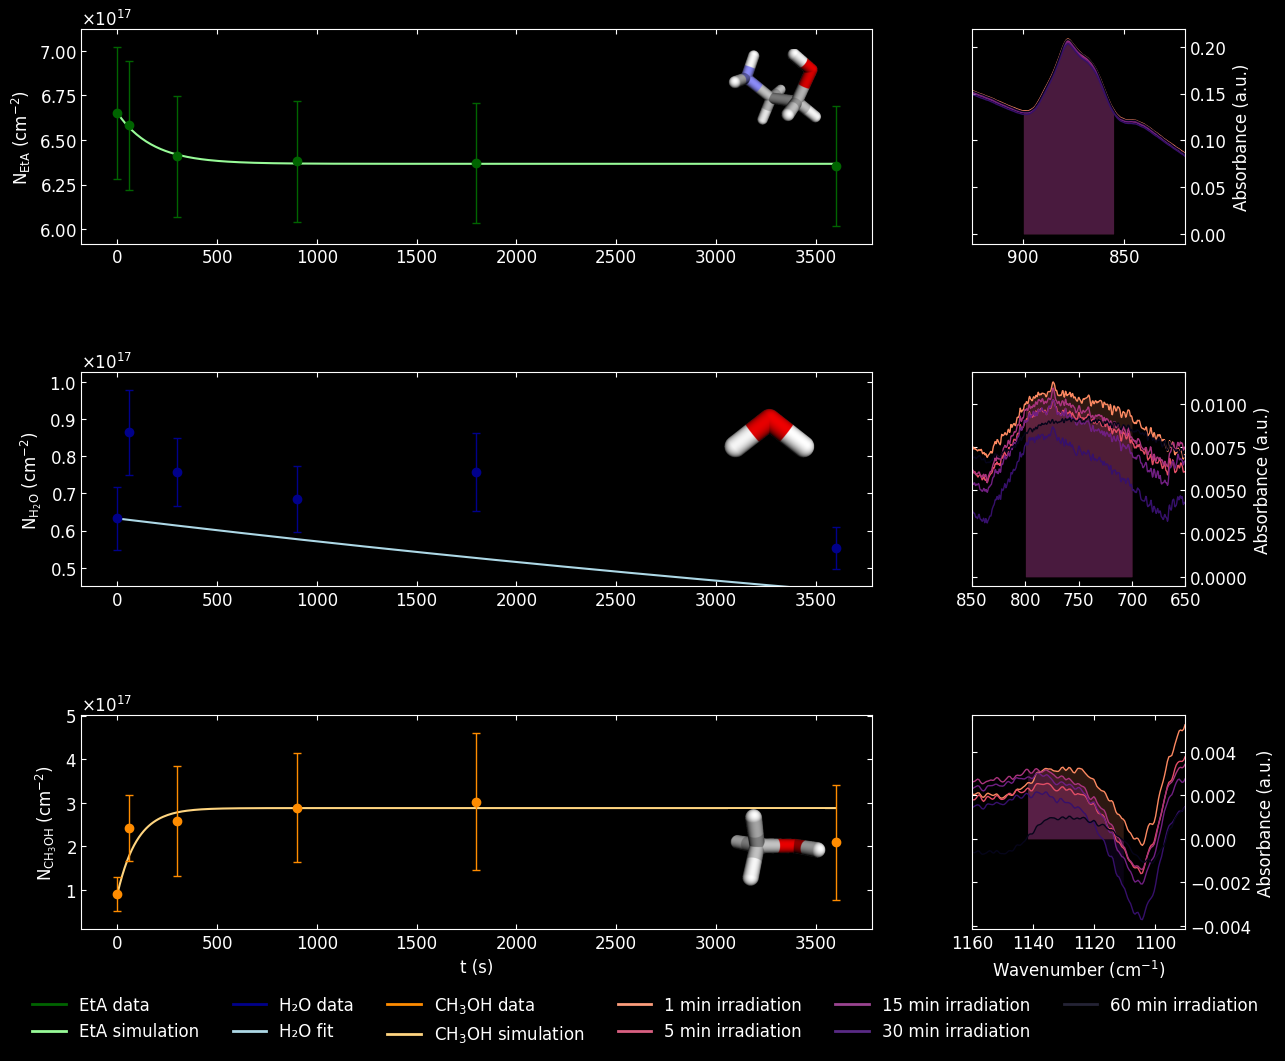


Gestapelter Plot gespeichert als:
  SVG: /home/tara/PyCharmMiscProject/MA_MPE/output/Simulation_1.svg
  PNG: /home/tara/PyCharmMiscProject/MA_MPE/output/Simulation_1.png
  PDF: /home/tara/PyCharmMiscProject/MA_MPE/output/Simulation_1.pdf


In [7]:
# each thickness was calculated using another script called Thickness_N_Calc_EtaH2OMeOH
# each S(t) was calculated in OMNIC, for that I calculated a Subtraction spectrum from the layered Ice before irradiation and the difference spectrum. This way the error of the
# initial N_0 was in the same dimension as N(t).

thickness_EtA_cm = 1.538059e-04
sigma_thickness_EtA_cm = 7.690294e-06

thickness_H2O_cm = 4.683683e-06
sigma_thickness_H2O_cm = 2.341842e-07

thickness_MeOH_cm = 1.402750e-05
sigma_thickness_MeOH_cm = 7.013749e-07

##EtA - Values
density_eta = 1.01
sigma_density_eta = 0.00

M_eta = 61.08
sigma_M_eta = 0.0

S0_eta = 7.057
sigma_S0_eta = 0.118  # = |abs| - |signed|
#895-855
S_irr_eta = np.array([6.983, 6.798, 6.770, 6.757, 6.743])  # signed integrals
sigma_S_irr_eta = np.array([0.101, 0.033, 0.049, 0.028, 0.033])  # = |abs| - |signed|
times_min_eta = np.array([1, 5, 15, 30, 60])
k_eta, dk_eta, Ninf_eta, dNinf_eta, t_eta, N_eta, sigma_N_eta, N0_eta = fit_parent_species(
    label="EtA",
    thickness_cm=thickness_EtA_cm,
    sigma_thickness_cm=sigma_thickness_EtA_cm,
    density_g_cm3=density_eta,
    sigma_density_g_cm3=sigma_density_eta,
    molar_mass_g_mol=M_eta,
    sigma_molar_mass_g_mol=sigma_M_eta,
    S0=S0_eta,
    sigma_S0=sigma_S0_eta,
    S_irr=S_irr_eta,
    sigma_S_irr=sigma_S_irr_eta,
    times_min=times_min_eta,
    absolute_S=True,
)

density_h2o = 0.93
sigma_density_h2o = 0.0

M_h2o = 18.015
sigma_M_h2o = 0.0

S0_h2o = 0.8083
sigma_S0_h2o = 0.072  # = |abs| - |signed|

S_irr_h2o = np.array([1.1052, 0.9685, 0.8749, 0.9678, 0.7081])  # signed integrals
sigma_S_irr_h2o = np.array([0.0917, 0.0642, 0.0721, 0.0905, 0.0038])  # = |abs| - |signed|
times_min_h2o = np.array([1, 5, 15, 30, 60])

k_h2o, dk_h2o, Ninf_h2o, dNinf_h2o, t_h2o, N_h2o, sigma_N_h2o, N0_h2o = fit_parent_species(
    label="H2O",
    thickness_cm=thickness_H2O_cm,
    sigma_thickness_cm=sigma_thickness_H2O_cm,
    density_g_cm3=density_h2o,
    sigma_density_g_cm3=sigma_density_h2o,
    molar_mass_g_mol=M_h2o,
    sigma_molar_mass_g_mol=sigma_M_h2o,
    S0=S0_h2o,
    sigma_S0=sigma_S0_h2o,
    S_irr=S_irr_h2o,
    sigma_S_irr=sigma_S_irr_h2o,
    times_min=times_min_h2o,
    absolute_S=True,
    ylim=None,

    model="compaction"
)

density_meoh = 0.779
sigma_density_meoh = 0.0

M_meoh = 32.04
sigma_M_meoh = 0.0

S0_meoh = 0.0313
sigma_S0_meoh = 0.0097  # = |abs| - |signed|

S_irr_meoh = np.array([0.0847, 0.0905, 0.1013, 0.1061, 0.0731])  # signed integrals
sigma_S_irr_meoh = np.array([0.001, 0.0344, 0.0305, 0.0442, 0.0407])  # = |abs| - |signed|
times_min_meoh = np.array([1, 5, 15, 30, 60])

k_meoh, dk_meoh, Ninf_meoh, dNinf_meoh, t_meoh, N_meoh, sigma_N_meoh, N0_meoh = fit_parent_species(
    label="MeOH",
    thickness_cm=thickness_MeOH_cm,
    sigma_thickness_cm=sigma_thickness_MeOH_cm,
    density_g_cm3=density_meoh,
    sigma_density_g_cm3=sigma_density_meoh,
    molar_mass_g_mol=M_meoh,
    sigma_molar_mass_g_mol=sigma_M_meoh,
    S0=S0_meoh,
    sigma_S0=sigma_S0_meoh,
    S_irr=S_irr_meoh,
    sigma_S_irr=sigma_S_irr_meoh,
    times_min=times_min_meoh,
    absolute_S=True,
    ylim=None,
)

print("\nZusammenfassung der k_eff:")
print(f"EtA : k_eff = {k_eta:.3e} ± {dk_eta:.3e} 1/s")
print(f"H2O : k_eff = {k_h2o:.3e} ± {dk_h2o:.3e} 1/s")
print(f"MeOH: k_eff = {k_meoh:.3e} ± {dk_meoh:.3e} 1/s")

times_min_chol = np.array([1, 5, 15, 30, 60])
S_chol1 = np.array([3.695, 3.726, 3.984, 3.701, 3.769])
sigma_S_chol1 = np.array([0.153, 0.15, 0.088, 0.096, 0.11]) # 915-875

k_chol1, dk_chol1, S_inf1, dS_inf1 = fit_choline_from_areas(
    label="Cholin Peak 1",
    S_chol=S_chol1,
    sigma_S_chol=sigma_S_chol1,
    times_min=times_min_chol,
)

print("\nCholin-Zusammenfassung:")
print(f"Peak 1: k_form = {k_chol1:.3e} ± {dk_chol1:.3e} 1/s")

t_span = (0.0, 3600.0)
t_eval = np.linspace(t_span[0], t_span[1], 300)

f_rad_eta    = 0.5
f_cholin_eta = 0.3
y0_eta = [N0_eta, 0.0, 0.0]
sol_eta = solve_ivp(
    fun=lambda t, y: eta_ode(t, y, k_eta, Ninf_eta, f_rad_eta, f_cholin_eta),
    t_span=t_span,
    y0=y0_eta,
    t_eval=t_eval,
    method="LSODA",
)
t_sim = sol_eta.t
E_sim_eta, R_sim_eta, C_sim_eta = sol_eta.y

W_sim = Ninf_h2o + (N0_h2o - Ninf_h2o) * np.exp(-k_h2o * t_sim)

f_dehyd = 0.3
f_CH3   = 0.4
f_OH    = 0.3
y0_meoh = [N0_meoh, 0.0, 0.0, 0.0]
sol_meoh = solve_ivp(
    fun=lambda t, y: meoh_ode(t, y, k_meoh, Ninf_meoh, f_dehyd, f_CH3, f_OH),
    t_span=t_span,
    y0=y0_meoh,
    t_eval=t_eval,
    method="LSODA",
)
M_sim, D_sim, CH3_sim, OH_sim = sol_meoh.y


# --- Load spectra from folders (Methanol / Water / EtA) ---
def find_file(folder, base, exts):
    for ext in exts:
        file_n = base + ext
        print(os.path.join(folder, file_n))
        p = os.path.join(folder, file_n)
        print(p)
        if os.path.exists(p):
            return p
    p2 = os.path.join(folder, base)
    if os.path.exists(p2):
        return p2
    return None

def read_two_columns(path):
    # Try simple splitting
    for sep in [None, ";", ",", "\t"]:
        try:
            wn, y = [], []
            with open(path, "r", errors="ignore") as f:
                for line in f:
                    line = line.strip()
                    if not line or line.startswith("#"):
                        continue
                    parts = line.split(sep) if sep is not None else line.split()
                    if len(parts) < 2:
                        continue
                    a0 = parts[0].replace(",", ".")
                    b0 = parts[1].replace(",", ".")
                    try:
                        wn.append(float(a0))
                        y.append(float(b0))
                    except Exception:
                        continue
            if len(wn) >= 5:
                return np.array(wn, float), np.array(y, float)
        except Exception:
            pass

    # Regex fallback (handles decimal comma)
    number_re = re.compile(r"[-+]?\d+(?:[.,]\d+)?(?:[eE][-+]?\d+)?")
    wn, y = [], []
    with open(path, "r", errors="ignore") as f:
        for line in f:
            nums = number_re.findall(line)
            if len(nums) >= 2:
                a0 = nums[0].replace(",", ".")
                b0 = nums[1].replace(",", ".")
                try:
                    wn.append(float(a0))
                    y.append(float(b0))
                except Exception:
                    continue
    return np.array(wn, float), np.array(y, float)

def load_spectra_set(folder, basenames, exts=None):
    if exts is None:
        exts = [".CSV"]  #  ".txt", ".dat", ".dpt", ".asc"
    spectra = []
    for base in basenames:
        path = find_file(folder, base, exts)
        print(path)
        if path is None:
            raise FileNotFoundError(f"Not found: {base} (+ {exts}) in\n{folder}")
        wn, y = read_two_columns(path)
        if wn.size == 0:
            raise ValueError(f"No valid numeric data read from: {path}")
        idx = np.argsort(wn)
        wn = wn[idx]
        y = y[idx]
        wn_u, uniq_idx = np.unique(wn, return_index=True)
        y_u = y[uniq_idx]
        spectra.append((base, wn_u, y_u))

    wn_ref = spectra[0][1]
    Y = []
    for name, wn, y in spectra:
        y_i = np.interp(wn_ref, wn, y)
        Y.append(y_i)
    Y = np.column_stack(Y)
    return wn_ref, Y, [s[0] for s in spectra]

# Windows paths (run this notebook locally on your machine)
meoh_dir = r"/home/tara/Sync/Methanol"
h2o_dir  = r"/home/tara/Sync/Water"
eta_dir  = r"/home/tara/Sync/Ethanolamine"

meoh_basenames = [f"Subtractionspectra_Methanol{i}" for i in range(1, 6)] + ["20240626_Deposition_Methanol_20K_sample1"]
h2o_basenames  = [f"Subtractionspectra_Water{i}" for i in range(1, 6)] + ["20240626_Deposition_H2O_20K_sample1"]
eta_basenames  = [f"Subtractionspectra_ETA{i}" for i in range(1, 6)] + ["20240626_Deposition_ZnSe_20K_sample1"]

print(meoh_dir, meoh_basenames)

wn_meoh, Y_meoh, names_meoh = load_spectra_set(meoh_dir, meoh_basenames)
wn_h2o,  Y_h2o,  names_h2o  = load_spectra_set(h2o_dir,  h2o_basenames)
wn_eta,  Y_eta,  names_eta  = load_spectra_set(eta_dir,  eta_basenames)

print(f"MeOH spectra loaded: {Y_meoh.shape[1]} spectra, {Y_meoh.shape[0]} points")
print(f"H2O  spectra loaded: {Y_h2o.shape[1]} spectra, {Y_h2o.shape[0]} points")
print(f"EtA  spectra loaded: {Y_eta.shape[1]} spectra, {Y_eta.shape[0]} points")

plt.rcParams.update({
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(3, 2, width_ratios=[3.7, 1.0], height_ratios=[1, 1, 1])
gs.update(wspace=0.2, hspace=0.6)
fig.subplots_adjust(left=0.08, right=1, top=0.98, bottom=0.08)

# -------------------------------------------------
# manual control over molecule positioning
# (x0, y0, width, height) in axis-coo (0..1)
# molecule boxes
ETA_INSET_BOX  = (0.7, 0.55, 0.36, 0.36)
H2O_INSET_BOX  = (0.75, 0.6, 0.24, 0.24)
MEOH_INSET_BOX = (0.7, 0.2, 0.36, 0.36)
# -------------------------------------------------
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))   # force 10^17
formatter.set_useOffset(False)

eta_formatter = ScalarFormatter(useMathText=True)
eta_formatter.set_scientific(True)
eta_formatter.set_powerlimits((17, 17))  # force 10^17
eta_formatter.set_useOffset(True)


ax_eta = fig.add_subplot(gs[0, 0])

ax_eta.plot(t_sim, E_sim_eta, color="#98FB98", label="EtA simulation")
ax_eta.plot(t_eta, N_eta, 'o', color="#006400", label="EtA data")


# --- Left axis limits (your code + your manual override) ---
eta_min = float(np.min(N_eta - sigma_N_eta))
eta_max = float(np.max(N_eta + sigma_N_eta))
eta_span = max(eta_max - eta_min, 1e-3)
pad_eta = 0.1 * eta_span
ax_eta.set_ylim(eta_min - pad_eta, eta_max + pad_eta)
ax_eta.set_ylabel(r"N$_{\mathrm{EtA}}$ (cm$^{-2}$)")
ax_eta.yaxis.set_major_formatter(eta_formatter)

ax_eta.errorbar(
    t_eta,
    N_eta,
    yerr=sigma_N_eta,
    fmt='none',
    ecolor="#006400",
    elinewidth=1,
    capsize=3,
)

safe_add_molecule_inset(
    ax_eta, eta_mol_png, "OCCN",
    loc="upper right", width="50%", height="50%",
    border=False, size_px=(300, 300), axes_box=ETA_INSET_BOX
)

for spine in ("top", "right"):
    ax_eta.spines[spine].set_visible(True)
ax_eta.tick_params(labelsize=12, axis="both",
        which="both",
        direction="in",
        top=True,
        labeltop=False,
        labelright=False)

ax_eta_spec = fig.add_subplot(gs[0, 1])
plot_spectra_panel(ax_eta_spec, wn_eta, Y_eta, eta_range_cm1, box_range=eta_box_cm1)
ax_eta_spec.tick_params(labelsize=12, axis="both",
        which="both",
        direction="in",
        top=True,
        left=True,
        right=True,
        labeltop=False,
        labelright=True)

###################################################################
ax_h2o = fig.add_subplot(gs[1, 0], sharex=ax_eta)
ax_h2o.plot(t_sim, W_sim, color="#ADD8E6", label="H$_2$O exponential fit")
ax_h2o.plot(t_h2o, N_h2o, 'o', color="#00008B", label="H$_2$O data")
ax_h2o.errorbar(
    t_h2o,
    N_h2o,
    yerr=sigma_N_h2o,
    fmt='none',
    ecolor="#00008B",
    elinewidth=1,
    capsize=3,
)


h2o_min = float(np.min(N_h2o - sigma_N_h2o))
h2o_max = float(np.max(N_h2o + sigma_N_h2o))
h2o_span = max(h2o_max - h2o_min, 1e-3)
pad_h2o = 0.1 * h2o_span
ax_h2o.set_ylim(h2o_min - pad_h2o, h2o_max + pad_h2o)
ax_h2o.set_ylabel(r"N$_{\mathrm{H_2O}}$ (cm$^{-2}$)")
ax_h2o.yaxis.set_major_formatter(formatter)

safe_add_molecule_inset(
    ax_h2o, h2o_mol_png, "O",
    loc="lower right", width="25%", height="25%",
    border=False, size_px=(300, 300), axes_box=H2O_INSET_BOX
)
for spine in ("top", "right"):
    ax_h2o.spines[spine].set_visible(True)
ax_h2o.tick_params(labelsize=12, axis="both",
        which="both",
        direction="in",
        top=True,
        right=True,
        labeltop=False,
        labelright=False)

ax_h2o_spec = fig.add_subplot(gs[1, 1])
plot_spectra_panel(ax_h2o_spec, wn_h2o, Y_h2o, h2o_range_cm1, box_range=h2o_box_cm1)
ax_h2o_spec.tick_params(labelsize=12, axis="both",
        which="both",
        direction="in",
        top=True,
        left=True,
        right=True,
        labeltop=False,
        labelright=True)


#################################################################
ax_meoh = fig.add_subplot(gs[2, 0], sharex=ax_eta)
ax_meoh.plot(t_sim, M_sim, color="#FFD580", label="CH$_3$OH simulation")
ax_meoh.plot(t_meoh, N_meoh, 'o', color="#FF8C00", label="CH$_3$OH data")
ax_meoh.errorbar(
    t_meoh,
    N_meoh,
    yerr=sigma_N_meoh,
    fmt='none',
    ecolor="#FF8C00",
    elinewidth=1,
    capsize=3,
)
meoh_min = float(np.min(N_meoh - sigma_N_meoh))
meoh_max = float(np.max(N_meoh + sigma_N_meoh))
meoh_span = max(meoh_max - meoh_min, 1e-3)
pad_meoh = 0.1 * meoh_span
ax_meoh.set_ylim(meoh_min - pad_meoh, meoh_max + pad_meoh)
ax_meoh.set_ylabel(r"N$_{\mathrm{CH_3OH}}$ (cm$^{-2}$)")
ax_meoh.set_xlabel("t (s)")
ax_meoh.yaxis.set_major_formatter(formatter)
safe_add_molecule_inset(
    ax_meoh, meoh_mol_png, "CO",
    loc="upper right", width="50%", height="50%",
    border=False, size_px=(300, 300), axes_box=MEOH_INSET_BOX
)
for spine in ("top", "right"):
    ax_meoh.spines[spine].set_visible(True)
ax_meoh.tick_params(labelsize=12, axis="both",
        which="both",
        direction="in",
        top=True,
        right=True,
        labeltop=False,
        labelright=False)

ax_meoh_spec = fig.add_subplot(gs[2, 1])
plot_spectra_panel(ax_meoh_spec, wn_meoh, Y_meoh, meoh_range_cm1, box_range=meoh_box_cm1)
ax_meoh_spec.set_xlabel(r"Wavenumber (cm$^{-1}$)")
ax_meoh_spec.tick_params(labelsize=12, axis="both",
        which="both",
        direction="in",
        top=True,
        right=True,
        left=True,
        labeltop=False,
        labelright=True)

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color="#006400", lw=2, label="EtA data"),
    Line2D([0], [0], color="#98FB98", lw=2, label="EtA simulation"),
    Line2D([0], [0], color="#00008B", lw=2, label="H₂O data"),
    Line2D([0], [0], color="#ADD8E6", lw=2, label="H₂O fit"),
    Line2D([0], [0], color="#FF8C00", lw=2, label="CH$_3$OH data"),
    Line2D([0], [0], color="#FFD580", lw=2, label="CH$_3$OH simulation"),
    Line2D([0], [0], color="#fc9d7c", lw=2, label="1 min irradiation"),
    Line2D([0], [0], color="#da6082", lw=2, label="5 min irradiation"),
    Line2D([0], [0], color="#9a4490", lw=2, label="15 min irradiation"),
    Line2D([0], [0], color="#592a85", lw=2, label="30 min irradiation"),
    Line2D([0], [0], color="#242335", lw=2, label="60 min irradiation"),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=6,
    frameon=True,
    bbox_to_anchor=(0.55, -0.05),
    fontsize=12,
    framealpha=0.4,
    edgecolor="black"
)


# fig.tight_layout()
plt.style.use("default")

fig.savefig(stacked_png, dpi=200, format="png", bbox_inches="tight", transparent=True)
fig.savefig(stacked_pdf, format="PDF", bbox_inches="tight")
fig.savefig(stacked_svg, format='svg', bbox_inches="tight")
plt.show()

print("\nGestapelter Plot gespeichert als:")
print("  SVG:", stacked_svg)
print("  PNG:", stacked_png)
print("  PDF:", stacked_pdf)
